In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates



In [2]:
# 1. Open the dataset (lazy by default; doesn’t read data until you ask for it)
ds = xr.open_dataset("/home/jupyter/data/dunmire25/OUTPUT/netcdfs/all_lakes_2019.nc")

# 2. Inspect its contents
print(ds)



<xarray.Dataset> Size: 162MB
Dimensions:      (ids: 6146, time: 365)
Coordinates:
  * ids          (ids) object 49kB 'SW2019_1110' 'SW2019_1390' ... 'SE2019_6101'
  * time         (time) datetime64[ns] 3kB 2019-01-01 2019-01-02 ... 2019-12-31
Data variables:
    S1_image_id  (ids, time) object 18MB ...
    S1_code      (ids, time) object 18MB ...
    HV_lake      (ids, time) float64 18MB ...
    HV_out       (ids, time) float64 18MB ...
    S2_water     (ids, time) float64 18MB ...
    S2_zenith    (ids, time) float64 18MB ...
    LS_water     (ids, time) float64 18MB ...
    LS_zenith    (ids, time) float64 18MB ...
    t2m          (ids, time) float64 18MB ...


In [3]:
# 1) Build a boolean mask: True where the id string contains "CW"
mask = ds.ids.str.contains("CW")

# 2a) Subset via .sel
ds_CW = ds.sel(ids=mask)
ds_CW


<xarray.Dataset> Size: 26MB
Dimensions:      (ids: 1000, time: 365)
Coordinates:
  * ids          (ids) object 8kB 'CW2019_2486' 'CW2019_2450' ... 'CW2019_2392'
  * time         (time) datetime64[ns] 3kB 2019-01-01 2019-01-02 ... 2019-12-31
Data variables:
    S1_image_id  (ids, time) object 3MB ...
    S1_code      (ids, time) object 3MB ...
    HV_lake      (ids, time) float64 3MB ...
    HV_out       (ids, time) float64 3MB ...
    S2_water     (ids, time) float64 3MB ...
    S2_zenith    (ids, time) float64 3MB ...
    LS_water     (ids, time) float64 3MB ...
    LS_zenith    (ids, time) float64 3MB ...
    t2m          (ids, time) float64 3MB ...

In [8]:
ds_CW

<xarray.Dataset> Size: 26MB
Dimensions:      (ids: 1000, time: 365)
Coordinates:
  * ids          (ids) object 8kB 'CW2019_2486' 'CW2019_2450' ... 'CW2019_2392'
  * time         (time) datetime64[ns] 3kB 2019-01-01 2019-01-02 ... 2019-12-31
Data variables:
    S1_image_id  (ids, time) object 3MB ...
    S1_code      (ids, time) object 3MB ...
    HV_lake      (ids, time) float64 3MB ...
    HV_out       (ids, time) float64 3MB ...
    S2_water     (ids, time) float64 3MB ...
    S2_zenith    (ids, time) float64 3MB ...
    LS_water     (ids, time) float64 3MB ...
    LS_zenith    (ids, time) float64 3MB ...
    t2m          (ids, time) float64 3MB ...

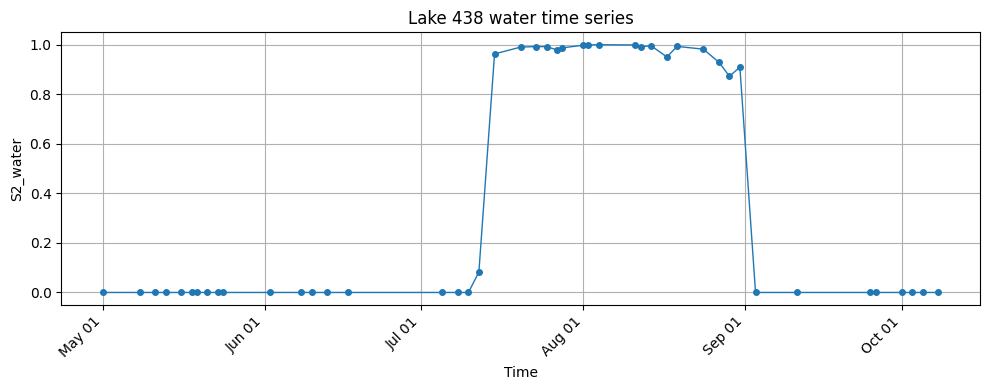

In [4]:


idx_lake = 438
times = ds_CW.time.values
values = ds_CW.S2_water[idx_lake].values

# drop NaNs
mask = ~np.isnan(values)
times = times[mask]
values = values[mask]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, values, 'o-', linewidth=1, markersize=4)

# set the major ticks to the 1st of each month
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))

# format those ticks however you like; here: “Jan 01” 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# rotate for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel("Time")
ax.set_ylabel("S2_water")
ax.set_title(f"Lake {idx_lake} water time series")
ax.grid(True)
plt.tight_layout()
plt.show()



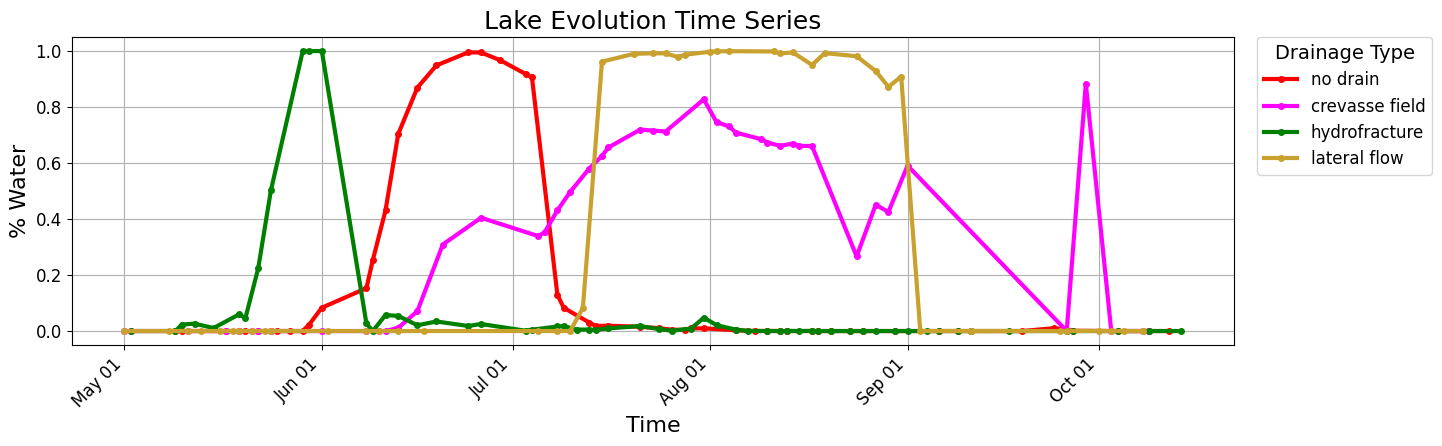

In [68]:


plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 18,    # title
    'axes.labelsize': 16,    # x/y labels
    'xtick.labelsize': 12,   # x‐tick labels
    'ytick.labelsize': 12,   # y‐tick labels
    'legend.fontsize': 12,   # legend text
    'legend.title_fontsize': 14
})

# lakes and their mustard‐adjusted colors
lake_ids = [40, 520, 365, 438]
colors = {
    40:  'red',
    520: 'magenta',
    365: 'green',
    438: '#C9A12F',    # mustard yellow
}

# one label per lake (in the same order as lake_ids)
laketype = [
    "no drain", 
    "crevasse field", 
    "hydrofracture", "lateral flow"
]

fig, ax = plt.subplots(figsize=(15, 4))

for idx_lake, lid in enumerate(lake_ids):
    vals = ds_CW.S2_water[lid].values
    mask = ~np.isnan(vals)
    t = ds_CW.time.values[mask]
    v = vals[mask]
    
    ax.plot(t, v, 'o-', 
            color=colors[lid],
            linewidth=3, 
            markersize=4,
            label=laketype[idx_lake])

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel("Time")
ax.set_ylabel("% Water")
ax.set_title("Lake Evolution Time Series")
ax.grid(True)

# place legend outside upper right
ax.legend(
    title="Drainage Type",
    loc='upper left',              # anchor the legend’s upper-left corner...
    bbox_to_anchor=(1.02, 1),      # … at x=1.02 (just outside), y=1 (top of axes)
    borderaxespad=0                # no padding between axes and legend
)
